This example shows how to extract the Single-Diode Model (SDM) parameters (e.g the light-induced current and series resistance) from "observed" IV curve data. 

In this case, the "observed" data consists of one IV curve that is simulated using pre-set SDM parameters at STC, just to demonstrate that the approach works

In [1]:
# !pip install pvlib
import itertools
import pandas as pd
import numpy as np
from pvlib import pvsystem, singlediode
from sklearn.metrics import mean_squared_error as mse
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

## 1. Get (generate in this case) and plot the "observed" data



Text(0, 0.5, 'Current [A]')

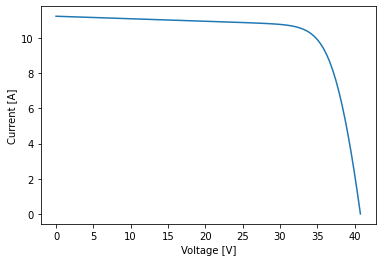

In [2]:
IL_obs, Io_obs, Rs_obs, Rsh_obs, a_obs = 11.26, 4.72e-11, 0.18, 69.97, 1.56 #the "true" SDM parameters of the "observed" data

iv_obs = pvsystem.singlediode(photocurrent=IL_obs, saturation_current=Io_obs, resistance_series=Rs_obs, resistance_shunt=Rsh_obs, nNsVth=a_obs, ivcurve_pnts=100)
v_obs, i_obs = iv_obs['v'], iv_obs['i']

fig, ax = plt.subplots()
ax.plot(v_obs, i_obs)
plt.xlabel('Voltage [V]')
plt.ylabel('Current [A]')

# 2. Define the fitting parameters

In [3]:
params = ['IL', 'Rsh']
labels = ['I$_L$', 'R$_{sh}$']
units = ['A', 'Ω']
param_ranges = [np.linspace(5, 15, 100), np.linspace(10, 1000, 100)]

combinations = list(itertools.product(*param_ranges)) #get all the possible parameter combinations
nb_params = len(params)

# 3. Define the Prior distribution and compute the Likelihood

In [4]:
bpe = pd.DataFrame(index=pd.MultiIndex.from_tuples(combinations, names=params))

bpe['Prior'] = 1/len(combinations) #assume that all the are combinations equiprobable
bpe['Error'] = np.nan

for cb in combinations:
    i_model = singlediode.bishop88_i_from_v(v_obs, photocurrent=cb[0], saturation_current=Io_obs, resistance_series=Rs_obs, resistance_shunt=cb[1], nNsVth=a_obs)

    bpe.loc[cb, 'Error'] = mse(i_obs, i_model) #the choice of error affects the final results

bpe['Likelihood'] = np.exp(-bpe['Error']) #assuming an exponential probability distribution

# 4. Calculate the Posterior distribution and find the best fits

In [5]:
bpe['Posterior'] = bpe['Prior']*bpe['Likelihood']/np.sum(bpe['Prior']*bpe['Likelihood'])

best_fits = bpe.sort_values(by=['Error'], ascending=True).head(10)
print('Best fits:')
print(best_fits[['Error', 'Posterior']])

Best fits:
                    Error  Posterior
IL        Rsh                       
11.262626 70.0   0.000007   0.000557
          80.0   0.001801   0.000556
11.161616 90.0   0.002076   0.000556
          100.0  0.002110   0.000556
11.262626 60.0   0.002607   0.000556
11.161616 110.0  0.003062   0.000556
11.363636 60.0   0.003321   0.000556
          50.0   0.003780   0.000555
11.161616 80.0   0.003782   0.000555
          120.0  0.004492   0.000555


## 5. Plot the marginal and conditional distributions

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:20: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.


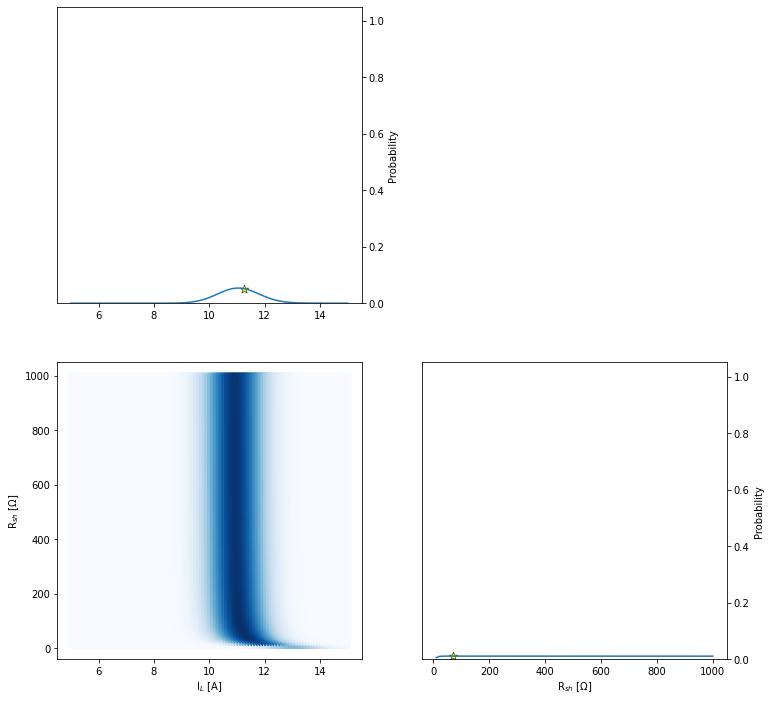

In [6]:
fig = plt.figure(figsize=(12, 12))
gs = GridSpec(nb_params, nb_params, figure=fig)

for i, param_range in enumerate(param_ranges):
    ax = fig.add_subplot(gs[i, i])

    # Marginal distributions of the individual parameters
    ax.plot(param_range, bpe.reset_index().groupby(params[i]).sum()['Posterior'])
    ax.scatter(best_fits.index[0][i], bpe.xs(best_fits.index[0][i], level=params[i])['Posterior'].sum(), s=80, marker='*', c='yellow', linewidths=0.5, edgecolors='black')
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position('right')
    ax.set_ylabel('Probability')
    ax.set_ylim([0, 1.05])
    if i == nb_params - 1:
        ax.set_xlabel(f'{labels[i]} [{units[i]}]')

    # Plot the relationship between any two parameters (conditional distributions)
    for pos in list(itertools.combinations(range(nb_params), 2)):
        x, y = pos[0], pos[1]
        ax = fig.add_subplot(gs[y, x])
        coupled_ranges = [param_ranges[x], param_ranges[y]]
        levels = [params[x], params[y]]
        coupled_combs = list(itertools.product(*coupled_ranges))
        if x==0:
            ax.set_ylabel(f'{labels[y]} [{units[y]}]')
        if y==nb_params-1:
            ax.set_xlabel(f'{labels[x]} [{units[x]}]')
        x = [coupled_comb[0] for coupled_comb in coupled_combs]
        y = [coupled_comb[1] for coupled_comb in coupled_combs]

        sc = ax.scatter(x, y, c=[bpe.xs(coupled_comb, level=levels)['Posterior'].sum() for coupled_comb in coupled_combs], cmap='Blues') #the dark blue region has the highest probability

# Visualize the top 5 fits

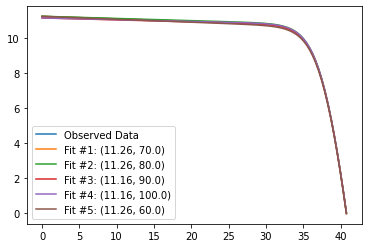

In [7]:
fig, ax = plt.subplots()
ax.plot(v_obs, i_obs, label='Observed Data')
for i, fit in enumerate(best_fits.index[:5]):
    i_fit = singlediode.bishop88_i_from_v(v_obs, photocurrent=fit[0], saturation_current=Io_obs, resistance_series=Rs_obs, resistance_shunt=fit[1], nNsVth=a_obs)
    ax.plot(v_obs, i_fit, label=f'Fit #{i+1}: {tuple(map(lambda x:round(x, 2), fit))}')
plt.legend()